In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np





In [ ]:
pt_data = pd.read_csv('public_trip_data.csv')
pt_event = pd.read_csv('public_trip_event_attributes.csv')
pt_log  = pd.read_csv('public_trip_event_log.csv')

#the private test_data
pt_data_test = pd.read_csv('private_trip_data.csv')
pt_event_test = pd.read_csv('private_trip_event_attributes.csv')
pt_log_test = pd.read_csv('private_trip_event_log.csv')

In [ ]:
pt_data.head ()

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,EmployeeNumber,BusinessUnit,HotelNights,NetCosts,Departure_CO2e,Return_CO2e,Hotel_CO2e,Spend_CO2e,TotalCO2e,HighCarbon
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,M1000-M5008,Services,1,900,1565.121857,1565.121857,58.9,1472.279257,3189.143714,0
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,M1000-M5030,Sales,2,3600,743.295848,743.295848,38.6,2921.504761,1525.191696,0
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,M1000-M5069,Services,1,450,1053.713528,1053.713528,51.4,743.646219,2158.827056,0
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,M1000-M5095,Executive Management,1,3450,196.262703,196.262703,6.7,3343.160260,399.225407,0
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,M1000-M5097,Marketing,2,1500,1053.713528,1053.713528,102.8,2478.820729,2210.227056,0


In [ ]:
pt_event.head()

,TripID,EmployeeNumber,TravelRequestID,ExpenseRequestID,ExpenseDenialReason,ExpenseReimbursementReason,ExpenseReimbursementAmount,ReasonForTransportCancellation,NewTransportSelection,ReasonForNewTransport,NewHotelSelection,ReasonForNewHotel,NewModeOfTransportation,TransportationPriceDifference,ReasonForTransportationChange,ReasonForDelay,ExtensionLength,DaysPreapproved,ProcessCode
0,1,M1000-M5008,TR000001,EXP000001,NaN,Policy exception approved,267.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
1,3,M1000-M5030,TR000003,EXP000003,NaN,Partial reimbursement,526.90,Personal emergency,Rebooked flight,Better schedule,NaN,NaN,Updated First Class Flight,140.62,Time constraints,NaN,NaN,2,V1
2,6,M1000-M5069,TR000006,EXP000006,NaN,Policy exception approved,487.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Weather delay,NaN,1,V1
3,7,M1000-M5095,TR000007,EXP000007,NaN,Policy exception approved,511.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
4,8,M1000-M5097,TR000008,EXP000008,NaN,Standard travel reimbursement,452.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mechanical issue,NaN,2,V20


In [ ]:
#this is for process mining!!
pt_log.head()

,TripID,StepOrder,EventName,EventTimestamp
0,1,1,Book Mode of Transportation,03/21/2024 23:36:20
1,1,2,Book Lodging,03/22/2024 09:16:16
2,1,3,Submit Travel Request,03/22/2024 12:15:19
3,1,4,Travel Request Approved,03/23/2024 08:12:58
4,1,5,Receive Confirmation,03/23/2024 23:42:47


In [ ]:
#lets look at all the columns
print(pt_data.shape)
print(pt_event.shape)
print(pt_log.shape)
#lets look at the columns for the private_test data
print(pt_data_test.shape)
print(pt_event_test.shape)
print(pt_log_test.shape)


(65289, 20)
(65289, 19)
(671547, 4)
(21764, 13)
(21764, 18)
(223819, 4)


object
object
int64


In [ ]:
# ---------- PUBLIC: build summaries ----------
pt_log_summary = pt_log.groupby("TripID").size().reset_index(name="num_events")

pt_event["had_cancellation"] = pt_event["ReasonForTransportCancellation"].notna()
pt_event_summary = pt_event.groupby("TripID")["had_cancellation"].max().reset_index()

# ---------- PUBLIC: merge ----------
final_df = pt_data.merge(pt_log_summary, on="TripID", how="left")
final_df = final_df.merge(pt_event_summary, on="TripID", how="left")
final_df["had_cancellation"] = final_df["had_cancellation"].fillna(False)
final_df["num_events"] = final_df["num_events"].fillna(0)

print("PUBLIC:", final_df.shape)
print(final_df.isnull().sum())

PUBLIC: (65289, 22)
TripID                      0
DepartureLocationCountry    0
DepartureLocationCity       0
ArrivalLocationCountry      0
ArrivalLocationCity         0
ShippingType                0
ShippingTypeDescription     0
Purpose                     0
OutOfPolicy                 0
EntitiyCode                 0
EmployeeNumber              0
BusinessUnit                0
HotelNights                 0
NetCosts                    0
Departure_CO2e              0
Return_CO2e                 0
Hotel_CO2e                  0
Spend_CO2e                  0
TotalCO2e                   0
HighCarbon                  0
num_events                  0
had_cancellation            0
dtype: int64


In [ ]:
# ---------- PRIVATE: build summaries ----------
pt_log_summary_test = pt_log_test.groupby("TripID").size().reset_index(name="num_events")

pt_event_test["had_cancellation"] = pt_event_test["ReasonForTransportCancellation"].notna()
pt_event_summary_test = pt_event_test.groupby("TripID")["had_cancellation"].max().reset_index()

# ---------- PRIVATE: merge ----------
final_df_test = pt_data_test.merge(pt_log_summary_test, on="TripID", how="left")
final_df_test = final_df_test.merge(pt_event_summary_test, on="TripID", how="left")
final_df_test["had_cancellation"] = final_df_test["had_cancellation"].fillna(False)
final_df_test["num_events"] = final_df_test["num_events"].fillna(0)

print("PRIVATE:", final_df_test.shape)
print(final_df_test.isnull().sum())

PRIVATE: (21764, 15)
TripID                      0
DepartureLocationCountry    0
DepartureLocationCity       0
ArrivalLocationCountry      0
ArrivalLocationCity         0
ShippingType                0
ShippingTypeDescription     0
Purpose                     0
OutOfPolicy                 0
EntitiyCode                 0
BusinessUnit                0
HotelNights                 0
NetCosts                    0
num_events                  0
had_cancellation            0
dtype: int64


In [ ]:
final_df.columns

Index(['TripID', 'DepartureLocationCountry', 'DepartureLocationCity',
       'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingType',
       'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EntitiyCode',
       'EmployeeNumber', 'BusinessUnit', 'HotelNights', 'NetCosts',
       'Departure_CO2e', 'Return_CO2e', 'Hotel_CO2e', 'Spend_CO2e',
       'TotalCO2e', 'HighCarbon', 'num_events', 'had_cancellation'],
      dtype='object')

In [ ]:
final_df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21764 entries, 0 to 21763
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   TripID                    21764 non-null  int64 
 1   DepartureLocationCountry  21764 non-null  object
 2   DepartureLocationCity     21764 non-null  object
 3   ArrivalLocationCountry    21764 non-null  object
 4   ArrivalLocationCity       21764 non-null  object
 5   ShippingType              21764 non-null  int64 
 6   ShippingTypeDescription   21764 non-null  object
 7   Purpose                   21764 non-null  object
 8   OutOfPolicy               21764 non-null  object
 9   EntitiyCode               21764 non-null  int64 
 10  BusinessUnit              21764 non-null  object
 11  HotelNights               21764 non-null  int64 
 12  NetCosts                  21764 non-null  int64 
 13  num_events                21764 non-null  int64 
 14  had_cancellation      

In [ ]:
print(final_df.info())
#any missng values
print('-'*30)
print(final_df.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65289 entries, 0 to 65288
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TripID                    65289 non-null  int64  
 1   DepartureLocationCountry  65289 non-null  object 
 2   DepartureLocationCity     65289 non-null  object 
 3   ArrivalLocationCountry    65289 non-null  object 
 4   ArrivalLocationCity       65289 non-null  object 
 5   ShippingType              65289 non-null  int64  
 6   ShippingTypeDescription   65289 non-null  object 
 7   Purpose                   65289 non-null  object 
 8   OutOfPolicy               65289 non-null  object 
 9   EntitiyCode               65289 non-null  int64  
 10  EmployeeNumber            65289 non-null  object 
 11  BusinessUnit              65289 non-null  object 
 12  HotelNights               65289 non-null  int64  
 13  NetCosts                  65289 non-null  int64  
 14  Depart

In [ ]:
print(final_df.duplicated().sum())
print(final_df.isnull().sum())
print('-'*60)
print(final_df_test.isnull().sum())

0
TripID                      0
DepartureLocationCountry    0
DepartureLocationCity       0
ArrivalLocationCountry      0
ArrivalLocationCity         0
ShippingType                0
ShippingTypeDescription     0
Purpose                     0
OutOfPolicy                 0
EntitiyCode                 0
EmployeeNumber              0
BusinessUnit                0
HotelNights                 0
NetCosts                    0
Departure_CO2e              0
Return_CO2e                 0
Hotel_CO2e                  0
Spend_CO2e                  0
TotalCO2e                   0
HighCarbon                  0
num_events                  0
had_cancellation            0
dtype: int64
------------------------------------------------------------
TripID                      0
DepartureLocationCountry    0
DepartureLocationCity       0
ArrivalLocationCountry      0
ArrivalLocationCity         0
ShippingType                0
ShippingTypeDescription     0
Purpose                     0
OutOfPolicy             

NameError: name 'trip_data' is not defined

In [ ]:
#lets look at our target variable!!
print(final_df['HighCarbon'].value_counts())

HighCarbon
0    48963
1    16326
Name: count, dtype: int64


In [ ]:
# How does HighCarbon rate differ across transport type?
print(final_df.groupby('ShippingTypeDescription')['HighCarbon'].mean().sort_values(ascending=False))

# How does it differ across trip purpose?
print(final_df.groupby('Purpose')['HighCarbon'].mean().sort_values(ascending=False))

# How does it differ by business unit?
print(final_df.groupby('BusinessUnit')['HighCarbon'].mean().sort_values(ascending=False))

ShippingTypeDescription
First Class Flight        0.628983
Business Class Flight     0.563685
Economy Flight            0.213812
BMW 3 diesel              0.106649
BMW 3 plugin hybrid       0.104450
Volkswagen Golf petrol    0.053256
Volkswagen Golf diesel    0.052091
Fiat 500 electric         0.050938
Train                     0.000000
Name: HighCarbon, dtype: float64
Purpose
Internal Business Trip    0.254450
Conference/Exhibition     0.252098
Partner Visit             0.251057
Enablement                0.248380
Customer Visit            0.247441
Name: HighCarbon, dtype: float64
BusinessUnit
Sustainability          0.308824
Ecosystem               0.268328
Services                0.252943
Sales                   0.252718
Customer Support        0.251874
Operations              0.248708
Legal                   0.247672
Marketing               0.247589
Executive Management    0.245845
Finance                 0.245590
Value Engineering       0.243135
Engineering             0.242597
Off

In [ ]:
# STEP 1: Add engineered features to PUBLIC data, BEFORE splitting
final_df['cost_per_hotel_night'] = final_df['NetCosts'] / (final_df['HotelNights'] + 1)
final_df['is_international'] = (final_df['DepartureLocationCountry'] != final_df['ArrivalLocationCountry']).astype(int)

# STEP 2: Add the SAME features to PRIVATE data
final_df_test['cost_per_hotel_night'] = final_df_test['NetCosts'] / (final_df_test['HotelNights'] + 1)
final_df_test['is_international'] = (final_df_test['DepartureLocationCountry'] != final_df_test['ArrivalLocationCountry']).astype(int)



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [ ]:
#ML pipeline
X = final_df.drop(columns = ['TripID',
                             'EmployeeNumber',
                             'Departure_CO2e',
                             'Return_CO2e', 'Hotel_CO2e',
                             'Spend_CO2e', 'TotalCO2e','HighCarbon'])
y = final_df['HighCarbon']

#train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X ,y ,test_size =0.2 , random_state=42,stratify = y)


In [ ]:
X_private = final_df_test.drop(columns=['TripID'])  # no leakage cols or HighCarbon here — they were never in private data

In [ ]:
print(X_train.shape)
print(X_test.shape)
print('-'*30)
print(X_train.columns)


(52231, 16)
(13058, 16)
------------------------------
Index(['DepartureLocationCountry', 'DepartureLocationCity',
       'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingType',
       'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EntitiyCode',
       'BusinessUnit', 'HotelNights', 'NetCosts', 'num_events',
       'had_cancellation', 'cost_per_hotel_night', 'is_international'],
      dtype='object')
cost_per_hotel_night    float64
is_international          int64
dtype: object


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
encoders = {}
#lets look at the cardianality for our columns!
for col in cat_cols:
 print(col,X_train[col].nunique())







DepartureLocationCountry 9
DepartureLocationCity 10
ArrivalLocationCountry 20
ArrivalLocationCity 26
ShippingTypeDescription 9
Purpose 5
OutOfPolicy 2
BusinessUnit 14


In [ ]:
onehot_cols = ['DepartureLocationCountry', 'DepartureLocationCity',
               'ShippingTypeDescription', 'Purpose', 'OutOfPolicy']

label_cols = ['ArrivalLocationCountry', 'ArrivalLocationCity','BusinessUnit']

Ohe = OneHotEncoder(handle_unknown= 'ignore', sparse_output= False,drop ='first')

Ohe.fit(X_train[onehot_cols])

train_ohe = pd.DataFrame(Ohe.transform(X_train[onehot_cols]), columns=Ohe.get_feature_names_out(onehot_cols), index=X_train.index)
test_ohe  = pd.DataFrame(Ohe.transform(X_test[onehot_cols]),  columns=Ohe.get_feature_names_out(onehot_cols), index=X_test.index)
private_ohe = pd.DataFrame(Ohe.transform(X_private[onehot_cols]), columns=Ohe.get_feature_names_out(onehot_cols), index=X_private.index)



#lets do it for our High Cardiniality Cat columns


label_encoders = {}

for col in label_cols:
  le = LabelEncoder()
  X_train[col] = le.fit_transform(X_train[col].astype(str))
  label_encoders[col] = le

def safe_transform(column, encoder):
    known = set(encoder.classes_)
    return column.astype(str).apply(lambda x: encoder.transform([x])[0] if x in known else -1).astype(int)


for col in label_cols:
    X_test[col] = safe_transform(X_test[col], label_encoders[col])
    X_private[col] = safe_transform(X_private[col], label_encoders[col])

# ---------- COMBINE EVERYTHING BACK TOGETHER ----------
X_train_final = pd.concat([X_train.drop(columns=onehot_cols), train_ohe], axis=1)
X_test_final = pd.concat([X_test.drop(columns=onehot_cols), test_ohe], axis=1)
X_private_final = pd.concat([X_private.drop(columns=onehot_cols), private_ohe], axis=1)

X_train_final = X_train_final.drop(columns=['ShippingType'], errors='ignore')
X_test_final = X_test_final.drop(columns=['ShippingType'], errors='ignore')
X_private_final = X_private_final.drop(columns=['ShippingType'], errors='ignore')
print(X_train_final.shape)
print(X_test_final.shape)
print(X_private_final.shape)














(52231, 40)
(13058, 40)
(21764, 40)


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final), columns=X_train_final.columns, index=X_train_final.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns, index=X_test_final.index)
X_private_scaled = pd.DataFrame(scaler.transform(X_private_final), columns=X_private_final.columns, index=X_private_final.index)

print(X_train_scaled.head())
print('-'*60)
print(X_train_scaled.columns)

       ArrivalLocationCountry  ArrivalLocationCity  EntitiyCode  BusinessUnit  \
47891               -0.840808            -0.162397    -0.008698     -1.892864   
21565                0.809660             1.387705    -1.421809     -1.892864   
5156                 1.109745            -0.317407     0.697857      0.675676   
2879                 1.109745             0.302633     0.697857     -0.608594   
50265               -1.591021            -1.247468    -0.715254     -0.351740   

       HotelNights  NetCosts  num_events  had_cancellation  \
47891     2.141841  0.664926    1.304748          3.994072   
21565    -0.658334  0.521961    0.543978         -0.250371   
5156     -1.358378  0.807892   -0.216793         -0.250371   
2879     -0.658334  0.950858   -0.216793          3.994072   
50265     0.741753 -0.335833   -0.216793         -0.250371   

       cost_per_hotel_night  is_international  ...  \
47891             -0.539792          0.303412  ...   
21565              0.666961     

In [ ]:
#is there any column mismatch?

print(sorted(X_train_final.columns) == sorted(X_train_scaled.columns))
print(set(X_train_final.columns) - set(X_train_scaled.columns))
print(set(X_train_scaled.columns) - set(X_train_final.columns))
print(X_train_final.shape, X_train_scaled.shape)

True
set()
set()
(52231, 40) (52231, 40)


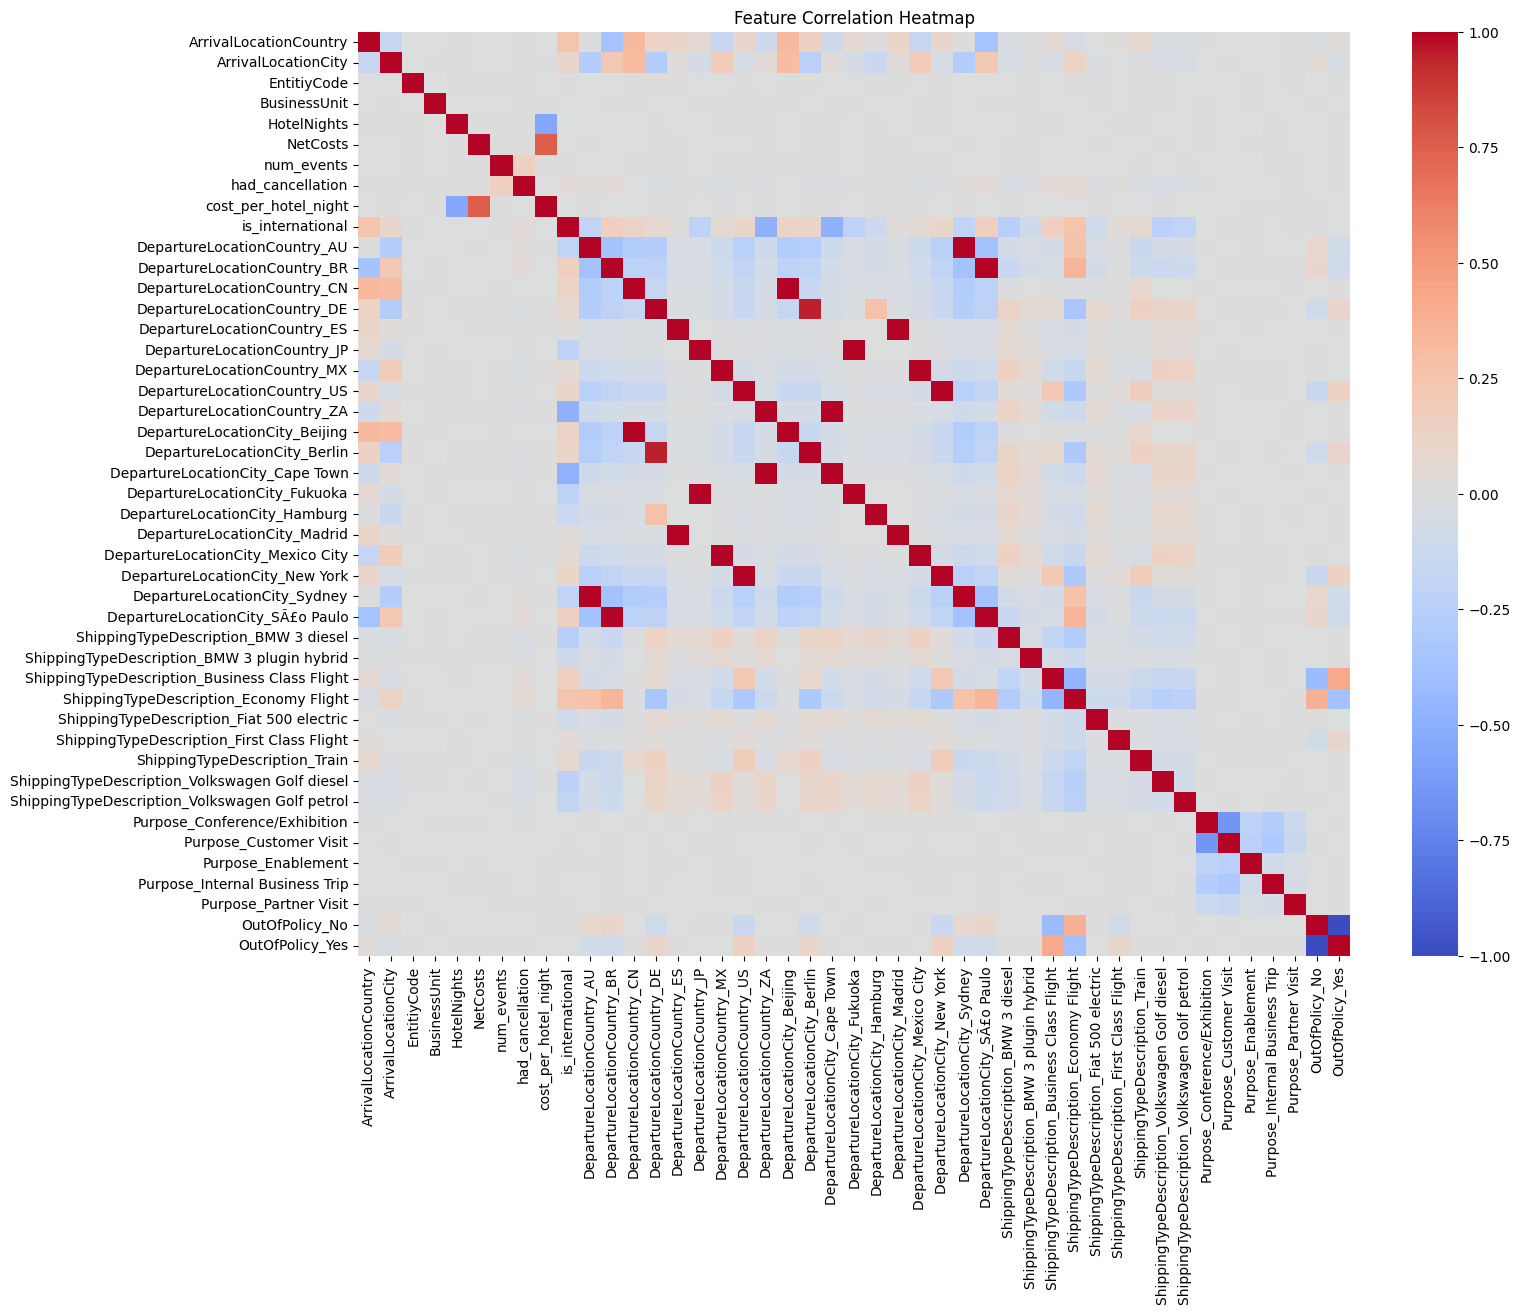

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = X_train_final.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# VIF requires numeric, non-constant columns — use your scaled train set
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]

vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                           feature       VIF
16                     DepartureLocationCountry_US       inf
17                     DepartureLocationCountry_ZA       inf
15                     DepartureLocationCountry_MX       inf
14                     DepartureLocationCountry_JP       inf
12                     DepartureLocationCountry_DE       inf
13                     DepartureLocationCountry_ES       inf
10                     DepartureLocationCountry_BR       inf
11                     DepartureLocationCountry_CN       inf
26                DepartureLocationCity_SÃ£o Paulo       inf
21                   DepartureLocationCity_Hamburg       inf
18                    DepartureLocationCity_Berlin       inf
19                 DepartureLocationCity_Cape Town       inf
22                    DepartureLocationCity_Madrid       inf
23               DepartureLocationCity_Mexico City       inf
25                    DepartureLocationCity_Sydney       inf
24                  Depa

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# Define each model, paired with the correct dataset
models = {
    "Logistic Regression": (LogisticRegression(class_weight='balanced', max_iter=1000), X_train_scaled, X_test_scaled),
    "Random Forest": (RandomForestClassifier(class_weight='balanced', random_state=42), X_train_final, X_test_final),
    "CatBoost": (CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42), X_train_final, X_test_final),
    "XGBoost": (xgb.XGBClassifier(scale_pos_weight=3, eval_metric='auc', random_state=42), X_train_final, X_test_final),
}

results = {}

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred_proba = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = auc
    print(f"{name}: ROC-AUC = {auc:.4f}")

print("\nBest model:", max(results, key=results.get))


Logistic Regression: ROC-AUC = 0.9394
Random Forest: ROC-AUC = 0.9967
CatBoost: ROC-AUC = 0.9994
XGBoost: ROC-AUC = 0.9994

Best model: XGBoost


In [ ]:
import pandas as pd

xgb_model = models["XGBoost"][0]
importances = pd.Series(xgb_model.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)
print(importances.head(15))

DepartureLocationCountry_AU                      0.284122
ShippingTypeDescription_Business Class Flight    0.244841
DepartureLocationCountry_DE                      0.099571
ArrivalLocationCountry                           0.064308
DepartureLocationCountry_US                      0.058558
DepartureLocationCountry_CN                      0.047560
ShippingTypeDescription_Economy Flight           0.040497
DepartureLocationCountry_BR                      0.039735
ShippingTypeDescription_First Class Flight       0.028660
ShippingTypeDescription_Train                    0.024714
ShippingTypeDescription_BMW 3 diesel             0.020025
HotelNights                                      0.012993
ArrivalLocationCity                              0.009242
ShippingTypeDescription_BMW 3 plugin hybrid      0.008264
is_international                                 0.004276
dtype: float32


True


In [ ]:
import pandas as pd

X_full = pd.concat([X_train_final, X_test_final], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

final_model = xgb.XGBClassifier(
     scale_pos_weight=3,
     eval_metric='auc',
     random_state=42)
final_model.fit(X_full, y_full)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
private_probs = final_model.predict_proba(X_private_final)[:, 1]
submission = pd.DataFrame({
    'TripID': final_df_test['TripID'],
    'HighCarbon': private_probs
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print(submission.shape)

   TripID  HighCarbon
0       2    0.999964
1       4    0.000669
2       5    0.957766
3      14    0.000069
4      15    0.000044
(21764, 2)
